<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/%5BTP4%5D_AA1_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 AA1


## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


# Setup Inicial del Notebook

### Imports

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Utils

In [8]:
def print_title(title):
    print('===' * 30)
    print(f' 🔷 {title}')
    print('===' * 30 + '\n')

#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

### Carga del Dataset

[URL Dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency)

In [39]:
# ⚠️ NOTA: El dataset se almacenó en GitHub debido  a que
# al intentar hacer fetch directamente al repositorio original (UCI Machine Learning)
# se generaba un error debido a la falta de certificados SSL en el sitio web original
url =  'https://github.com/fernandolievano/aprendizaje-automatico-1/raw/refs/heads/main/ENB2012_data.xlsx'
df = pd.read_excel(url)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


> Se seleccionó el dataset **Energy Efficiency** para este trabajo práctico. El dataset cumple con cada de los requisitos, posee múltiples variables continuas (X1, X2, X3, X4, X5 y X7), junto con variables objetivo continuas (Y1 y Y2), permitiendonos aplicar modelos de regresión lineal. También presenta variables con distintas escalas y no contiene valores faltantes, facilitando su procesamiento y análisis.


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

### 2.1 Objetivo

> El objetivo de esta etapa es comprender las variables del dataset y su comportamiento antes de pasar al procesamiento de datos. Para ello, se procederá a observar la distribución de los datos, analizar la variabilidad de las features y detectar posibles outliers, para así, poder tener una visión más amplia de la estructura de los datos.

### 2.2 Descripción general de los datos

In [11]:
print_title('Forma del Dataset')
print(f'--> {df.shape}')

 🔷 Forma del Dataset

--> (768, 10)


> El dataset cuenta con 768 filas y 10 columnas.

In [24]:
print_title('Descripción de las variables')

variable_descriptions = [
    'Compactación Relativa',
    'Área de Superficie',
    'Área de Muro',
    'Área de Techo',
    'Altura Total',
    'Orientación',
    'Área de Acristalamiento',
    'Distribución del Área de Acristalamiento',
    'Carga de Calefacción',
    'Carga de Enfriamiento'
]

for i, col in enumerate(df.columns):
    print(f'-> {col}: {variable_descriptions[i]}')

 🔷 Descripción de las variables

-> X1: Compactación Relativa
-> X2: Área de Superficie
-> X3: Área de Muro
-> X4: Área de Techo
-> X5: Altura Total
-> X6: Orientación
-> X7: Área de Acristalamiento
-> X8: Distribución del Área de Acristalamiento
-> Y1: Carga de Calefacción
-> Y2: Carga de Enfriamiento


> Información complementaria extraída de UCI Machine Learning Repository — Energy Efficiency Dataset
https://archive.ics.uci.edu/dataset/242/energy+efficiency

In [26]:
print_title('Tipos de variables')

df_types = df.dtypes.reset_index()
df_types.columns = ['Variable', 'Tipo']

df_types

 🔷 Tipos de variables



,Variable,Tipo
0,X1,float64
1,X2,float64
2,X3,float64
3,X4,float64
4,X5,float64
5,X6,int64
6,X7,float64
7,X8,int64
8,Y1,float64
9,Y2,float64


 > Se observa que la mayoría de variables corresponden a valores numéricos continuos (float64), salvo X6 y X8 que están representadas como valores  int64, variables que representan variables discretas que brindan información sobre orientación y distribución del área de acristalamiento respectivamente.

In [31]:
print_title('Variables Objetivo (target)')

df[['Y1', 'Y2']].sample(5)

 🔷 Variables Objetivo (target)



,Y1,Y2
741,39.72,39.80
492,25.70,26.53
17,29.90,31.27
109,24.23,25.02
634,32.05,30.11


> La documentación oficial del dataset indica que las variables Y1 (Carga de calefacción) y Y2 (Carga de enfriamiento) son los targets, mientras que las variables X1 a X8 representan las features del dataset.

>Para este trabajo práctico, se utilizará **Y2** como target principal.

### 2.3 Estadísticas descriptivas

In [33]:
df.describe().round(2)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


> A partir de las estadísticas descripticas se puede observar que hay variables con diferentes rangos y niveles de variabilidad. Algunas features como X2 y X3 cuentan con valores más altos que otras features como X1 o X7.

### 2.4 Distribución de variables

 🔷 Distribución del target



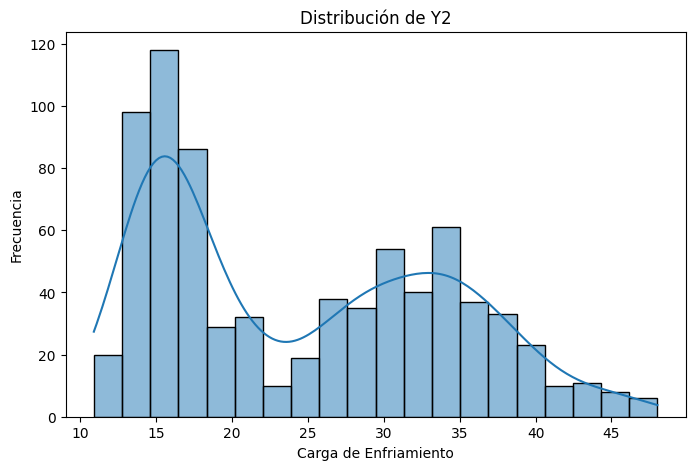

In [67]:
print_title('Distribución del target')

plt.figure(figsize=(8,5))
sns.histplot(df['Y2'], bins=20, kde=True)

plt.title('Distribución de Y2')
plt.xlabel('Carga de Enfriamiento')
plt.ylabel('Frecuencia')
plt.show()


> Se observa en el histograma que la variable objetivo Y2 tiene dos concentraciones de observaciones en valores bajos y medios, lo que indica una posible distribución bimodal. No se perciben outliers a primera vista y se puede apreciar una leve asimetría hacia los valores más altos.

 🔷 Distribución de features X2, X5 y X7



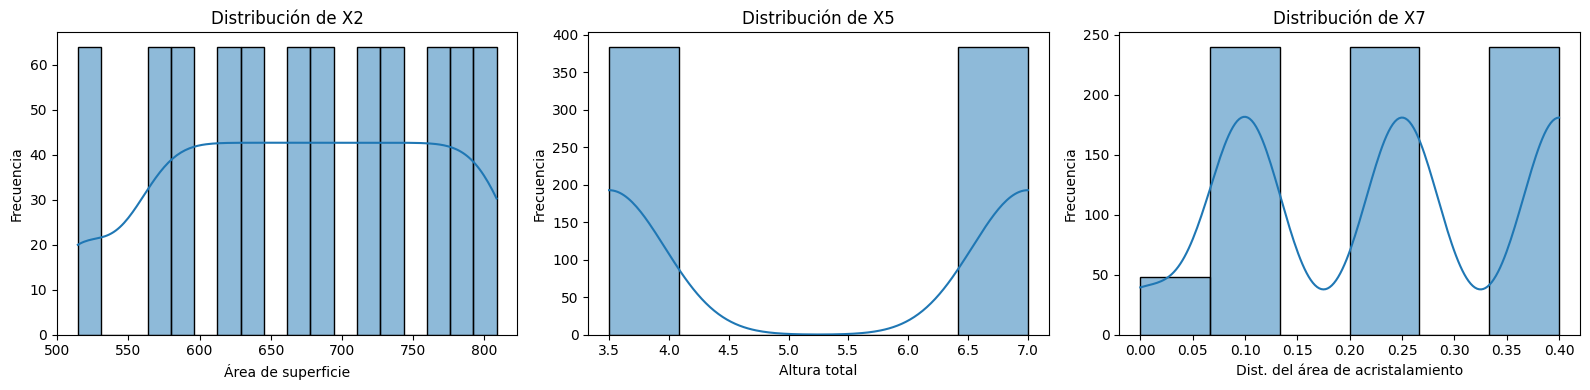

In [65]:
print_title('Distribución de features X2, X5 y X7')

# figura principal
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# histograma X2
sns.histplot(df['X2'], bins=12, kde=True, ax=axes[0])
axes[0].set_title('Distribución de X2')
axes[0].set_xlabel('Área de superficie')
axes[0].set_ylabel('Frecuencia')

# histograma X5
sns.histplot(df['X5'], bins=6, kde=True, ax=axes[1])
axes[1].set_title('Distribución de X5')
axes[1].set_xlabel('Altura total')
axes[1].set_ylabel('Frecuencia')

# histograma x7
sns.histplot(df['X7'], bins=6, kde=True, ax=axes[2])
axes[2].set_title('Distribución de X7')
axes[2].set_xlabel('Dist. del área de acristalamiento')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

> La variable X2 tiene una distribución uniforme mostrando una buena variabilidad y una dispersión amplia de observaciones. Lo que sugiere que la feature tiene suficiente diversidad de datos para resultar útil durante el modelado.
>
> En el caso de X5, presenta una distribución discreta, ya que concentra sus observaciones en dos valores principales que denotan distintas alturas de construcción.
>
> Mientras X7 presenta una distribución discreta con varias concentraciones en valores específicos.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  



## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe


# 7. Referencias

### Uso de IA

- [Chat usado para scaffolding del Notebook](https://chatgpt.com/share/6a1297c9-3f70-83e9-8e7f-c6153eec4b22)

### Documentación

- [Repositorio oficial del Dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency)